# Kyiv Air-Raid Alerts — Duration vs. Time-of-Day and Attack Scale

This notebook builds an end-to-end, reproducible pipeline that:

1. **Collects** historical air-raid alert records for **Kyiv** (start, end, duration).
2. **Enriches** each alert with **environmental** data — sunrise/sunset, day/night,
   moon phase, and weather (cloud cover, temperature, precipitation, wind).
3. **Adds weapons** data — type and quantity of munitions per attack (drones, cruise,
   ballistic) from the Ukrainian Air Force daily reports (piterfm / CSIS Strike Tracker).
4. **Tests two hypotheses** with appropriate statistics:
   - **H1** — Do the *longest* alerts cluster at particular times of day (day vs. night,
     morning vs. evening)?
   - **H2** — Are the longest alerts associated with the *most massive* attacks
     (does duration relate to the number and/or type of weapons)?
5. **Visualizes** the distributions and the relationships found.

### Data sources & honest caveats
| Layer | Source | Status in this run |
|---|---|---|
| Alerts | `alerts.com.ua` API → fallback to the official **Vadimkin** GitHub dataset (same official data) | **REAL** |
| Sun / moon | `astral` (computed locally, no network) | **REAL** |
| Weather | **Open-Meteo** historical archive API (free, no key) | **REAL only** — missing hours flagged, never synthesised |
| Weapons | **Kaggle** `piterfm/massive-missile-attacks-on-ukraine` (the dataset behind the CSIS Strike Tracker) | real if a Kaggle token is present, else a clearly-labelled **synthetic** stand-in |

Two structural caveats baked into the analysis:
- **Weapons are reported as daily / per-wave national aggregates**, so a weapon type is
  attached to an alert at the *night* level, not as the proven cause of that specific siren.
  H2 is therefore an ecological (day-level) association, not alert-level causation.
- Alerts are **clustered in waves** and strongly autocorrelated; ordinary p-values overstate
  significance. We report effect sizes alongside p-values and keep claims modest.

## Setup — imports and configuration

In [1]:
# Core
import warnings, io, sys, json, time, math, datetime as dt
from pathlib import Path

import numpy as np
import pandas as pd
import requests

# Stats
from scipy import stats
import statsmodels.formula.api as smf

# Sun / moon (computed offline)
from astral import LocationInfo
from astral.sun import sun, elevation as solar_elevation
from astral.moon import phase as moon_phase

# Plotting
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": .25, "font.size": 10})
RNG = np.random.default_rng(42)          # determinism for any synthetic fallback

# ---- Configuration -----------------------------------------------------------
KYIV_LAT, KYIV_LON = 50.4501, 30.5234    # Kyiv city centre
TZ                 = "Europe/Kyiv"        # local time (EET/EEST, handles DST)
OUTDIR             = Path("outputs"); OUTDIR.mkdir(exist_ok=True)

# Official air-raid dataset (no auth, updated daily) — used as the reliable backbone.
ALERTS_CSV_URL = ("https://raw.githubusercontent.com/Vadimkin/"
                  "ukrainian-air-raid-sirens-dataset/main/datasets/official_data_en.csv")
ALERTS_COM_UA_API = "https://alerts.com.ua/api/states"   # tried first if reachable

print("Config ready — analysing Kyiv at", (KYIV_LAT, KYIV_LON), "in", TZ)

Config ready — analysing Kyiv at (50.4501, 30.5234) in Europe/Kyiv


## Step 1 — Air-raid alert data for Kyiv

We try the public `alerts.com.ua` endpoint first (as requested). Its public surface is
geared to *current* status and its history needs auth, so when a clean history isn't
available we fall back to the **official** air-raid dataset on GitHub (Vadimkin), which is
the *same* official source, exposes `started_at` / `finished_at`, and needs no key.

We keep **Kyiv City**, city-wide (`oblast`-level) alerts — a consistent unit across the whole
period — and compute each alert's **duration in minutes**.

In [2]:
def _clean_kyiv(df: pd.DataFrame) -> pd.DataFrame:
    # Standardise columns, keep Kyiv-City city-wide alerts, compute duration.
    df = df.rename(columns=str.lower)
    df["started_at"]  = pd.to_datetime(df["started_at"],  utc=True, errors="coerce")
    df["finished_at"] = pd.to_datetime(df["finished_at"], utc=True, errors="coerce")
    m = (df["oblast"] == "Kyiv City") & (df["level"] == "oblast")
    df = df.loc[m, ["started_at", "finished_at"]].dropna()
    # Drop impossible / zero-length records gracefully
    df["duration_min"] = (df["finished_at"] - df["started_at"]).dt.total_seconds() / 60
    df = df[(df["duration_min"] > 0) & (df["duration_min"] < 24*60)]   # <24h sanity bound
    return df.sort_values("started_at").reset_index(drop=True)

def fetch_alerts_com_ua():
    # Attempt the alerts.com.ua public API. Returns a DataFrame or raises.
    r = requests.get(ALERTS_COM_UA_API, timeout=15)
    r.raise_for_status()
    data = r.json()
    # The public endpoint mainly serves *current* state, not full history with end-times,
    # so we deliberately treat it as insufficient for a duration study and fall back.
    raise RuntimeError("alerts.com.ua public endpoint lacks historical end-times; "
                       "falling back to the official dataset.")

def fetch_alerts_official():
    # Official air-raid dataset (Vadimkin) - reliable historical backbone.
    r = requests.get(ALERTS_CSV_URL, timeout=60); r.raise_for_status()
    return pd.read_csv(io.StringIO(r.text))

def load_alerts() -> pd.DataFrame:
    try:
        raw = fetch_alerts_com_ua()
        src = "alerts.com.ua"
    except Exception as e:
        print("ℹ️  alerts.com.ua not used:", str(e).split(";")[0])
        raw = fetch_alerts_official()
        src = "official GitHub dataset (Vadimkin)"
    out = _clean_kyiv(raw)
    print(f"✅ Loaded {len(out):,} Kyiv city-wide alerts from {src}")
    print(f"   range: {out['started_at'].min():%Y-%m-%d} → {out['started_at'].max():%Y-%m-%d}")
    return out

alerts = load_alerts()
alerts.head()

ℹ️  alerts.com.ua not used: alerts.com.ua public endpoint lacks historical end-times
✅ Loaded 3,961 Kyiv city-wide alerts from official GitHub dataset (Vadimkin)
   range: 2022-03-15 → 2026-06-23


,started_at,finished_at,duration_min
0,2022-03-15 16:19:20+00:00,2022-03-15 18:52:28+00:00,153.133333
1,2022-03-15 16:19:20+00:00,2022-03-15 18:52:28+00:00,153.133333
2,2022-03-15 23:33:47+00:00,2022-03-16 03:41:56+00:00,248.150000
3,2022-03-15 23:33:47+00:00,2022-03-16 03:41:56+00:00,248.150000
4,2022-03-16 04:12:47+00:00,2022-03-16 04:54:31+00:00,41.733333


## Step 2 — Environmental enrichment

For each alert we add, aligned to its **local** start time and Kyiv's coordinates:

* **Local time features** — local start timestamp, hour, day-part bin.
* **Sun** — sunrise / sunset that day, a **day vs. night** flag, and the **solar elevation
  angle** at the alert's start (degrees above/below the horizon). Computed offline with
  `astral`, so always available.
* **Moon phase** — 0–28 (`astral`): 0 ≈ new, 7 ≈ first-quarter, 14 ≈ full, 21 ≈ last-quarter.
* **Weather (REAL)** — hourly cloud cover, temperature, precipitation and wind from the
  **Open-Meteo historical archive API** (free, no key), matched to each alert's local hour.

> **No synthetic weather.** We fetch real values only. Any hour the API doesn't return is
> left as `NaN` and **flagged** (a coverage report is printed) — never imputed or mocked.
> If the API is unreachable in your environment the weather columns stay all-`NaN` and the
> weather hypothesis (H3) reports "data unavailable" instead of inventing numbers.

We then build an **illumination index** = `max(0, sin(solar_elevation)) × (1 − cloud_fraction)`
— a 0→1 proxy for how much daylight actually reaches the ground, combining sun position with
cloud cover. It is `NaN` wherever cloud cover is missing.

In [3]:
LOC = LocationInfo("Kyiv", "Ukraine", TZ, KYIV_LAT, KYIV_LON)

# --- local time + day-part ----------------------------------------------------
alerts["start_local"] = alerts["started_at"].dt.tz_convert(TZ)
alerts["date_local"]  = alerts["start_local"].dt.date
alerts["hour_local"]  = alerts["start_local"].dt.hour + alerts["start_local"].dt.minute/60

def day_part(h):
    if   5 <= h < 12: return "morning"
    elif 12 <= h < 17: return "afternoon"
    elif 17 <= h < 22: return "evening"
    else:              return "night"          # 22:00–05:00
alerts["day_part"] = alerts["hour_local"].apply(day_part)

# --- sun (sunrise/sunset, day/night), solar elevation, moon phase -------------
def sun_moon_for_date(d):
    try:
        s = sun(LOC.observer, date=d, tzinfo=LOC.timezone)
        return pd.Series({"sunrise": s["sunrise"], "sunset": s["sunset"],
                          "moon_phase": moon_phase(d)})
    except Exception:
        return pd.Series({"sunrise": pd.NaT, "sunset": pd.NaT, "moon_phase": np.nan})

uniq = pd.DataFrame({"date_local": sorted(alerts["date_local"].unique())})
uniq = pd.concat([uniq, uniq["date_local"].apply(sun_moon_for_date)], axis=1)
alerts = alerts.merge(uniq, on="date_local", how="left")

def is_night(row):
    if pd.isna(row["sunrise"]) or pd.isna(row["sunset"]):
        return np.nan
    return not (row["sunrise"] <= row["start_local"] <= row["sunset"])
alerts["is_night"] = alerts.apply(is_night, axis=1)

# Solar elevation (deg) at the exact local start time of each alert.
alerts["solar_elev"] = [solar_elevation(LOC.observer, t) for t in alerts["start_local"]]
print(f"Day/night split — night: {alerts['is_night'].mean():.1%} of alerts start in darkness")
print(f"Solar elevation range: {alerts['solar_elev'].min():.1f}° … {alerts['solar_elev'].max():.1f}°")

Day/night split — night: 51.7% of alerts start in darkness
Solar elevation range: -62.8° … 62.8°


### Weather — real Open-Meteo data only (missing stays missing)

In [4]:
WX_VARS = ["temp_c", "cloud_pct", "precip_mm", "wind_kmh"]

def fetch_weather_year(y0, y1):
    # One Open-Meteo archive request for a [y0, y1] date span; returns hourly local-time rows.
    url = ("https://archive-api.open-meteo.com/v1/archive"
           f"?latitude={KYIV_LAT}&longitude={KYIV_LON}"
           f"&start_date={y0}&end_date={y1}"
           "&hourly=temperature_2m,cloudcover,precipitation,wind_speed_10m"
           f"&timezone={TZ.replace('/','%2F')}")
    r = requests.get(url, timeout=90); r.raise_for_status()
    h = r.json()["hourly"]
    w = pd.DataFrame(h)
    w["time"] = pd.to_datetime(w["time"]).dt.tz_localize(
        TZ, nonexistent="shift_forward", ambiguous="NaT")
    return w.rename(columns={"temperature_2m": "temp_c", "cloudcover": "cloud_pct",
                             "precipitation": "precip_mm", "wind_speed_10m": "wind_kmh"})

def load_weather(dates):
    # Fetch year-by-year so a single failed chunk doesn't lose everything.
    # NOTHING is synthesised: a year that fails contributes only NaNs (flagged later).
    frames, years = [], sorted({d.year for d in dates})
    for y in years:
        d0, d1 = f"{y}-01-01", f"{y}-12-31"
        try:
            frames.append(fetch_weather_year(d0, d1))
            print(f"   ✓ {y}: weather retrieved")
        except Exception as e:
            print(f"   ✗ {y}: weather UNAVAILABLE ({str(e)[:55]}) — left missing")
    if not frames:
        return None
    return pd.concat(frames).drop_duplicates("time").set_index("time").sort_index()

print("Fetching real historical weather from Open-Meteo …")
wx = load_weather(alerts["date_local"].unique())

# Initialise weather columns as missing, then fill ONLY from real data where available.
for c in WX_VARS:
    alerts[c] = np.nan
if wx is not None:
    key = alerts["start_local"].dt.floor("h")
    aligned = wx.reindex(key)                 # missing hours -> NaN (no interpolation)
    for c in WX_VARS:
        alerts[c] = aligned[c].to_numpy()

# --- coverage report (flag missingness; do not fill) --------------------------
WEATHER_AVAILABLE = alerts["cloud_pct"].notna().any()
print("\nWeather coverage (real values present per variable):")
for c in WX_VARS:
    n_ok = int(alerts[c].notna().sum())
    print(f"   {c:10s}: {n_ok:5d}/{len(alerts)} alerts ({n_ok/len(alerts):5.1%})  "
          f"| missing {len(alerts)-n_ok}")
if not WEATHER_AVAILABLE:
    print("\n⚠️  No real weather retrieved in this environment — weather columns are all NaN.\n"
          "    H3 will report 'data unavailable'. Re-run on an open network to populate it.")

# --- illumination index = clear-sky daylight x (1 - cloud fraction) -----------
clear_sky = np.clip(np.sin(np.radians(alerts["solar_elev"])), 0, None)   # 0 at/below horizon
alerts["illumination"] = clear_sky * (1 - alerts["cloud_pct"]/100.0)     # NaN where cloud NaN

alerts[["start_local","is_night","solar_elev","cloud_pct","temp_c","precip_mm","illumination"]].head()

Fetching real historical weather from Open-Meteo …
   ✓ 2022: weather retrieved
   ✓ 2023: weather retrieved
   ✓ 2024: weather retrieved
   ✓ 2025: weather retrieved
   ✗ 2026: weather UNAVAILABLE (400 Client Error: Bad Request for url: https://archive-) — left missing

Weather coverage (real values present per variable):
   temp_c    :  3638/3961 alerts (91.8%)  | missing 323
   cloud_pct :  3638/3961 alerts (91.8%)  | missing 323
   precip_mm :  3638/3961 alerts (91.8%)  | missing 323
   wind_kmh  :  3638/3961 alerts (91.8%)  | missing 323


,start_local,is_night,solar_elev,cloud_pct,temp_c,precip_mm,illumination
0,2022-03-15 18:19:20+02:00,True,-3.422877,62.0,6.8,0.0,0.0
1,2022-03-15 18:19:20+02:00,True,-3.422877,62.0,6.8,0.0,0.0
2,2022-03-16 01:33:47+02:00,True,-38.002888,88.0,-1.9,0.0,0.0
3,2022-03-16 01:33:47+02:00,True,-38.002888,88.0,-1.9,0.0,0.0
4,2022-03-16 06:12:47+02:00,False,0.160716,100.0,-4.1,0.0,0.0


## Step 3 — Weapons data (type & quantity per attack)

The structured record of what Russia launched each night comes from the Ukrainian Air
Force daily reports, compiled by **Petro Ivaniuk** as the Kaggle dataset
`piterfm/massive-missile-attacks-on-ukraine` — **the same data CSIS uses** in its
[Russian Firepower Strike Tracker](https://www.csis.org/programs/futures-lab/projects/russian-firepower-strike-tracker-analyzing-missile-attacks-ukraine).
`missile_attacks_daily.csv` has one row per weapon model per attack wave, with
`time_start`, `time_end`, `model`, `launched`, `destroyed`, and an affected-region field.

Downloading it needs a (free) Kaggle token. With one present we use the real data; without
one we generate a **clearly-labelled synthetic** table with the *same schema* so the merge
and the statistics run identically. We aggregate to one row per **attack night**:
total launched, total destroyed, distinct models, and `has_shahed / has_cruise / has_ballistic`.

In [5]:
SHAHED   = ["Shahed", "Geran", "UAV", "BpLA"]
CRUISE   = ["Kh-101", "Kh-555", "Kalibr", "Kh-59", "Kh-22", "Iskander-K"]
BALLISTIC= ["Iskander-M", "Kinzhal", "KN-23", "S-300", "ballistic"]

def classify_model(m):
    m = str(m)
    if any(k.lower() in m.lower() for k in BALLISTIC): return "ballistic"
    if any(k.lower() in m.lower() for k in CRUISE):    return "cruise"
    if any(k.lower() in m.lower() for k in SHAHED):    return "shahed"
    return "other"

def load_weapons_kaggle():
    # Real path: requires `pip install kagglehub` + a Kaggle token in the env.
    import kagglehub
    p = kagglehub.dataset_download("piterfm/massive-missile-attacks-on-ukraine")
    f = next(Path(p).rglob("missile_attacks_daily.csv"))
    df = pd.read_csv(f)
    df["time_start"] = pd.to_datetime(df["time_start"], errors="coerce")
    df["time_end"]   = pd.to_datetime(df.get("time_end"), errors="coerce")
    return df

def synthesize_weapons(dates):
    # Synthetic stand-in with the real schema (one row per model per wave).
    rows = []
    for d in dates:
        if RNG.random() < 0.45:                       # ~45% of nights see a wave
            n_models = RNG.integers(1, 4)
            for mdl in RNG.choice(["Shahed-136","Kh-101","Iskander-M","Kalibr","Kinzhal"],
                                  size=n_models, replace=False):
                base = RNG.integers(40, 600) if "Shahed" in mdl else RNG.integers(1, 25)
                launched = int(base)
                rows.append(dict(time_start=pd.Timestamp(d)+pd.Timedelta(hours=int(RNG.integers(18,23))),
                                 model=mdl, launched=launched,
                                 destroyed=int(launched*RNG.uniform(.5,.95))))
    return pd.DataFrame(rows)

WEAPONS_IS_SYNTHETIC = False
try:
    wdf = load_weapons_kaggle()
    print("✅ Weapons pulled from Kaggle (real)")
except Exception as e:
    WEAPONS_IS_SYNTHETIC = True
    print("⚠️  Kaggle unavailable here →  SYNTHETIC weapons (schema-identical, NOT real):",
          str(e).splitlines()[0][:70])
    wdf = synthesize_weapons(sorted(alerts["date_local"].unique()))

# --- aggregate to one row per attack night -----------------------------------
wdf = wdf.dropna(subset=["time_start"]).copy()
wdf["wclass"]      = wdf["model"].apply(classify_model)
wdf["attack_date"] = pd.to_datetime(wdf["time_start"]).dt.date
g = wdf.groupby("attack_date")
weapons_nightly = pd.DataFrame({
    "total_launched":  g["launched"].sum(),
    "total_destroyed": g["destroyed"].sum(),
    "n_models":        g["model"].nunique(),
    "has_shahed":      g["wclass"].apply(lambda s: (s=="shahed").any()),
    "has_cruise":      g["wclass"].apply(lambda s: (s=="cruise").any()),
    "has_ballistic":   g["wclass"].apply(lambda s: (s=="ballistic").any()),
}).reset_index()
print(f"{len(weapons_nightly):,} attack-nights aggregated. Synthetic={WEAPONS_IS_SYNTHETIC}")
weapons_nightly.head()

✅ Weapons pulled from Kaggle (real)
800 attack-nights aggregated. Synthetic=False


,attack_date,total_launched,total_destroyed,n_models,has_shahed,has_cruise,has_ballistic
0,2022-09-29,7.0,5.0,1,True,False,False
1,2022-10-01,1.0,1.0,1,False,False,False
2,2022-10-02,7.0,5.0,1,True,False,False
3,2022-10-05,2.0,2.0,2,True,False,False
4,2022-10-06,8.0,8.0,3,True,False,False


### Merge weapons → alerts (night-level)

A wave that starts at, say, 22:00 produces sirens past midnight, so an alert is attributed
to the **previous** evening's wave when it starts before ~14:00 local. This is a documented
heuristic, not a proven causal link (weapons are national/daily aggregates).

In [6]:
# Attribute each alert to an "attack night": same local date if it began at/after 14:00,
# otherwise the previous calendar date (post-midnight tail of the prior evening's wave).
alerts["attack_date"] = np.where(
    alerts["hour_local"] >= 14,
    pd.to_datetime(alerts["date_local"]),
    pd.to_datetime(alerts["date_local"]) - pd.Timedelta(days=1)
)
alerts["attack_date"] = alerts["attack_date"].dt.date

df = alerts.merge(weapons_nightly, on="attack_date", how="left")

# Nights with no recorded massive attack → 0 weapons (a real, meaningful zero, not missing).
for c in ["total_launched","total_destroyed","n_models"]:
    df[c] = df[c].fillna(0)
for c in ["has_shahed","has_cruise","has_ballistic"]:
    df[c] = df[c].fillna(False).astype(bool)   # real bool so ~mask works correctly

print(f"Merged dataset: {len(df):,} alerts | "
      f"{(df['total_launched']>0).mean():.0%} matched to a recorded attack night")
df[["start_local","duration_min","day_part","is_night","total_launched","has_ballistic"]].head()

Merged dataset: 3,961 alerts | 53% matched to a recorded attack night


,start_local,duration_min,day_part,is_night,total_launched,has_ballistic
0,2022-03-15 18:19:20+02:00,153.133333,evening,True,0.0,False
1,2022-03-15 18:19:20+02:00,153.133333,evening,True,0.0,False
2,2022-03-16 01:33:47+02:00,248.150000,night,True,0.0,False
3,2022-03-16 01:33:47+02:00,248.150000,night,True,0.0,False
4,2022-03-16 06:12:47+02:00,41.733333,morning,False,0.0,False


## Step 4 — Statistical analysis

`duration_min` is strongly right-skewed, so we analyse it with **rank-based tests**
(Mann–Whitney, Kruskal–Wallis, Spearman) and use `log10(duration)` for the regression.
We report **effect sizes** next to p-values, because waves make alerts non-independent and
inflate significance.

### H1 — Do the longest alerts cluster at particular times of day?

In [7]:
def epsilon_squared(H, n):           # effect size for Kruskal–Wallis
    return (H - 0) / ((n**2 - 1)/(n + 1))

def rank_biserial(u, n1, n2):        # effect size for Mann–Whitney
    return 1 - (2*u)/(n1*n2)

d = df.dropna(subset=["is_night"]).copy()

# (a) Day vs night — Mann–Whitney U on duration
night = d.loc[d["is_night"], "duration_min"]
day   = d.loc[~d["is_night"], "duration_min"]
u, p_mw = stats.mannwhitneyu(night, day, alternative="two-sided")
print("H1(a) DAY vs NIGHT")
print(f"   median duration — night {night.median():.1f} min | day {day.median():.1f} min")
print(f"   Mann–Whitney U={u:,.0f}, p={p_mw:.3g}, rank-biserial r={rank_biserial(u,len(night),len(day)):+.3f}")

# (b) Four day-parts — Kruskal–Wallis
groups = [g["duration_min"].values for _,g in d.groupby("day_part")]
H, p_kw = stats.kruskal(*groups)
print("\nH1(b) DAY-PART (morning/afternoon/evening/night)")
print(d.groupby("day_part")["duration_min"].agg(["count","median","mean"]).round(1).to_string())
print(f"   Kruskal–Wallis H={H:.1f}, p={p_kw:.3g}, epsilon^2={epsilon_squared(H,len(d)):.3f}")

# (c) Do the *longest* alerts (top quartile) cluster on the 24h clock? — Rayleigh test
def rayleigh(hours):
    ang = 2*np.pi*hours/24.0
    C, S = np.cos(ang).sum(), np.sin(ang).sum()
    n = len(ang); R = np.hypot(C, S)/n
    z = n*R**2
    p = np.exp(-z)*(1 + (2*z - z**2)/(4*n) - (24*z - 132*z**2 + 76*z**3 - 9*z**4)/(288*n**2))
    mean_hour = (math.atan2(S, C) % (2*np.pi))*24/(2*np.pi)
    return R, p, mean_hour
thresh = d["duration_min"].quantile(0.75)
longest = d.loc[d["duration_min"] >= thresh, "hour_local"].values
R, p_ray, mean_hr = rayleigh(longest)
print(f"\nH1(c) Longest alerts (≥{thresh:.0f} min, n={len(longest)}) on the 24h clock")
print(f"   Rayleigh R={R:.3f}, p={p_ray:.3g}  (low p ⇒ they cluster, not uniform)")
print(f"   mean concentration ≈ {int(mean_hr):02d}:{int(mean_hr%1*60):02d} local")

H1(a) DAY vs NIGHT
   median duration — night 49.4 min | day 32.3 min
   Mann–Whitney U=2,456,904, p=1.38e-43, rank-biserial r=-0.254

H1(b) DAY-PART (morning/afternoon/evening/night)
           count  median  mean
day_part                      
afternoon    799    31.9  47.0
evening      772    32.3  61.6
morning      950    35.6  58.9
night       1440    56.8  99.1
   Kruskal–Wallis H=230.7, p=9.61e-50, epsilon^2=0.058

H1(c) Longest alerts (≥87 min, n=994) on the 24h clock
   Rayleigh R=0.373, p=6.84e-60  (low p ⇒ they cluster, not uniform)
   mean concentration ≈ 01:31 local


### H2 — Are the longest alerts associated with the most massive attacks?

In [8]:
print("H2(a) Duration vs ATTACK SCALE (Spearman, rank-based)")
sub = df[df["total_launched"] > 0]                       # nights with a recorded attack
for col, lab in [("total_launched","total munitions launched"),
                 ("n_models","# distinct weapon models")]:
    rho, p = stats.spearmanr(sub["duration_min"], sub[col])
    print(f"   duration vs {lab:28s}: rho={rho:+.3f}, p={p:.3g}  (n={len(sub)})")

print("\nH2(b) Duration by WEAPON TYPE present (Mann–Whitney)")
for flag in ["has_ballistic","has_cruise","has_shahed"]:
    a = df.loc[df[flag],  "duration_min"]
    b = df.loc[~df[flag], "duration_min"]
    if len(a) and len(b):
        u, p = stats.mannwhitneyu(a, b, alternative="two-sided")
        print(f"   {flag:14s}: median {a.median():6.1f} vs {b.median():6.1f} min | "
              f"U={u:,.0f}, p={p:.3g}, r={rank_biserial(u,len(a),len(b)):+.3f}")

print("\nH2(c) Multivariate model — log10(duration) on scale + type + time + season")
m = df.copy()
m["log_dur"]   = np.log10(m["duration_min"])
m["night"]     = m["is_night"].astype(float)
m["month"]     = pd.to_datetime(m["start_local"]).dt.month
m["launched100"] = m["total_launched"]/100.0          # per-100-munitions coefficient
fml = ("log_dur ~ night + launched100 + has_ballistic + has_cruise + C(month)")
ols = smf.ols(fml, data=m).fit(cov_type="HC3")        # robust SEs
keep = [t for t in ols.params.index if not t.startswith("C(month)") and t!="Intercept"]
res = pd.DataFrame({"coef":ols.params[keep], "p":ols.pvalues[keep]}).round(4)
print(res.to_string())
print(f"   R^2={ols.rsquared:.3f}  (month fixed-effects absorb seasonal/campaign confounding)")
if WEAPONS_IS_SYNTHETIC:
    print("\n   🔸 NOTE: weapons are SYNTHETIC in this run — H2 numbers are a methodology demo.")

H2(a) Duration vs ATTACK SCALE (Spearman, rank-based)
   duration vs total munitions launched    : rho=+0.072, p=0.000938  (n=2085)
   duration vs # distinct weapon models    : rho=+0.077, p=0.000472  (n=2085)

H2(b) Duration by WEAPON TYPE present (Mann–Whitney)
   has_ballistic : median   35.7 vs   39.6 min | U=1,163,096, p=0.532, r=+0.015
   has_cruise    : median   49.2 vs   38.6 min | U=647,878, p=9.58e-06, r=-0.152
   has_shahed    : median   37.7 vs   40.1 min | U=1,955,253, p=0.946, r=-0.001

H2(c) Multivariate model — log10(duration) on scale + type + time + season
                         coef       p
has_ballistic[T.True] -0.1055  0.0000
has_cruise[T.True]     0.0821  0.0076
night                  0.1698  0.0000
launched100            0.0382  0.0000
   R^2=0.100  (month fixed-effects absorb seasonal/campaign confounding)


### H3 — Does alert duration relate to weather (illumination, temperature, precipitation)?

The hypothesis: alerts run longer in **low-illumination** conditions — darkness and/or heavy
cloud make incoming drones and missiles harder to see and intercept — and we also probe
**temperature** and **precipitation**. We test, on the rows that have **real** weather:

1. Each continuous predictor vs. `duration_min` with **Spearman** rank correlation
   (robust to the heavy right-skew): `cloud_pct`, `temp_c`, `precip_mm`, `solar_elev`,
   and the combined `illumination` index.
2. A **multivariate OLS** on `log10(duration)` to see what survives together, controlling for
   season (month fixed-effects).
3. The key disentangling test: `illumination` is largely a continuous version of day/night,
   and H1 already showed night ⇒ longer. So we add a model with **`solar_elev`, `cloud_pct`
   and their interaction** to ask whether **cloud cover adds anything beyond sun position** —
   i.e. is it really *illumination*, or just *night*?

Every test runs only on non-missing rows; the n used (and n missing) is printed. If no real
weather is present, H3 says so rather than fabricating a result.

In [9]:
if not WEATHER_AVAILABLE:
    print("⚠️  No real weather in this run — H3 skipped. Re-run on an open network "
          "(Open-Meteo) to populate weather and compute these statistics.")
else:
    print("H3(a) Duration vs each weather predictor — Spearman (real rows only)")
    preds = {"cloud_pct":"cloud cover (%)", "temp_c":"temperature (°C)",
             "precip_mm":"precipitation (mm)", "solar_elev":"solar elevation (°)",
             "illumination":"illumination index"}
    for col, lab in preds.items():
        s = df[["duration_min", col]].dropna()
        rho, p = stats.spearmanr(s["duration_min"], s[col])
        print(f"   duration vs {lab:22s}: rho={rho:+.3f}, p={p:.3g}  "
              f"(n={len(s)}, missing={len(df)-len(s)})")

    print("\nH3(b) Multivariate OLS — log10(duration) ~ illumination + temp + precip + season")
    m = df.copy()
    m["log_dur"] = np.log10(m["duration_min"])
    m["month"]   = pd.to_datetime(m["start_local"]).dt.month
    cols = ["log_dur","illumination","temp_c","precip_mm","month"]
    m = m[cols].dropna()
    ols = smf.ols("log_dur ~ illumination + temp_c + precip_mm + C(month)",
                  data=m).fit(cov_type="HC3")
    keep = [t for t in ols.params.index if not t.startswith("C(month)") and t!="Intercept"]
    print(pd.DataFrame({"coef":ols.params[keep], "p":ols.pvalues[keep]}).round(4).to_string())
    print(f"   n={int(ols.nobs)}, R^2={ols.rsquared:.3f}")

    print("\nH3(c) Is it illumination or just night? — cloud effect beyond sun position")
    m2 = df[["duration_min","solar_elev","cloud_pct","start_local"]].dropna().copy()
    m2["log_dur"] = np.log10(m2["duration_min"])
    m2["month"]   = m2["start_local"].dt.month
    ols2 = smf.ols("log_dur ~ solar_elev * cloud_pct + C(month)",
                   data=m2).fit(cov_type="HC3")
    for term in ["solar_elev","cloud_pct","solar_elev:cloud_pct"]:
        if term in ols2.params:
            print(f"   {term:22s}: coef={ols2.params[term]:+.5f}, p={ols2.pvalues[term]:.3g}")
    print(f"   n={int(ols2.nobs)}, R^2={ols2.rsquared:.3f}")
    print("   → a significant negative cloud_pct (and/or interaction) supports the "
          "illumination hypothesis beyond the day/night effect.")

H3(a) Duration vs each weather predictor — Spearman (real rows only)
   duration vs cloud cover (%)       : rho=+0.043, p=0.00922  (n=3638, missing=323)
   duration vs temperature (°C)      : rho=-0.214, p=5.9e-39  (n=3638, missing=323)
   duration vs precipitation (mm)    : rho=-0.020, p=0.223  (n=3638, missing=323)
   duration vs solar elevation (°)   : rho=-0.255, p=1.22e-59  (n=3961, missing=0)
   duration vs illumination index    : rho=-0.209, p=3.23e-37  (n=3638, missing=323)

H3(b) Multivariate OLS — log10(duration) ~ illumination + temp + precip + season
                coef       p
illumination -0.2667  0.0000
temp_c       -0.0067  0.0000
precip_mm    -0.0261  0.1084
   n=3638, R^2=0.067

H3(c) Is it illumination or just night? — cloud effect beyond sun position
   solar_elev            : coef=-0.00346, p=2.61e-19
   cloud_pct             : coef=-0.00006, p=0.709
   solar_elev:cloud_pct  : coef=+0.00000, p=0.653
   n=3638, R^2=0.098
   → a significant negative cloud_pct (and/o

## Step 5 — Visualisation

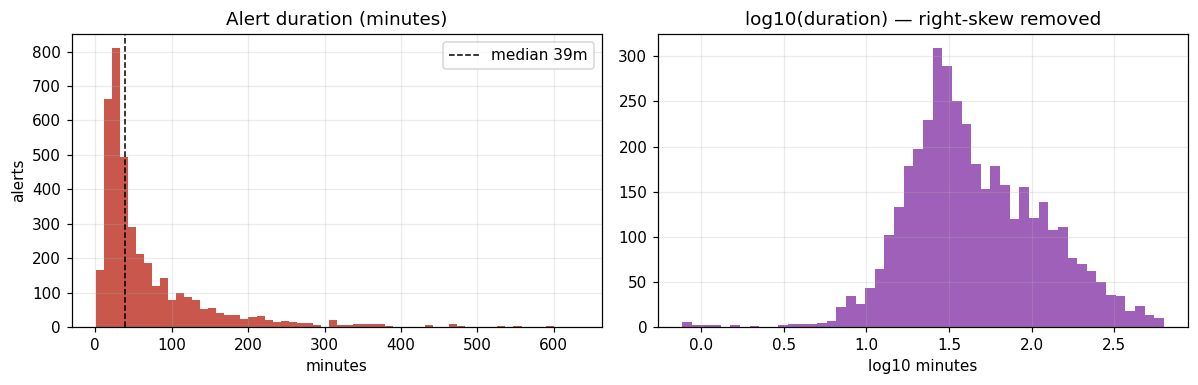

In [10]:
# Fig 1 — duration distribution (raw + log)
fig, ax = plt.subplots(1, 2, figsize=(11,3.6))
ax[0].hist(df["duration_min"], bins=60, color="#c0392b", alpha=.85)
ax[0].set(title="Alert duration (minutes)", xlabel="minutes", ylabel="alerts")
ax[0].axvline(df["duration_min"].median(), color="k", ls="--", lw=1,
              label=f'median {df["duration_min"].median():.0f}m'); ax[0].legend()
ax[1].hist(np.log10(df["duration_min"]), bins=50, color="#8e44ad", alpha=.85)
ax[1].set(title="log10(duration) — right-skew removed", xlabel="log10 minutes")
plt.tight_layout(); plt.savefig(OUTDIR/"fig1_duration_distribution.png", bbox_inches="tight"); plt.show()

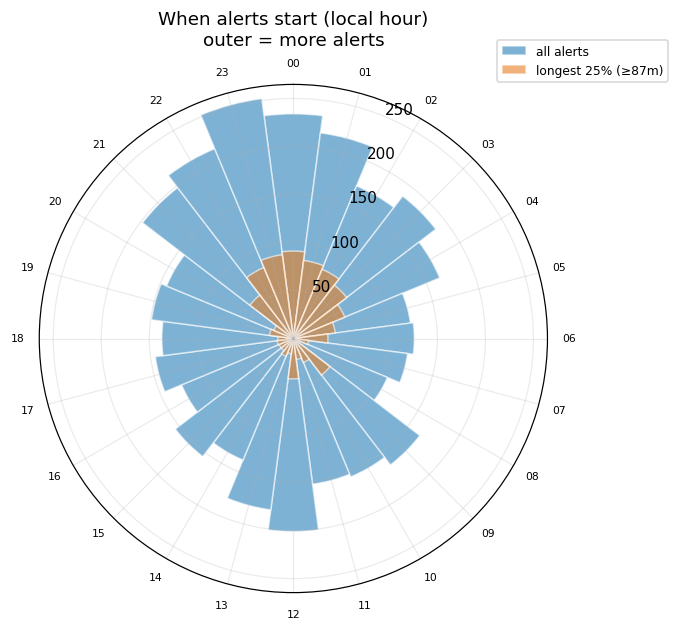

In [11]:
# Fig 2 — start times across the 24h clock (polar rose); longest alerts overlaid
def rose(ax, hours, color, label):
    counts, edges = np.histogram(hours % 24, bins=24, range=(0,24))
    theta = (edges[:-1])/24*2*np.pi
    ax.bar(theta, counts, width=2*np.pi/24, color=color, alpha=.6,
           edgecolor="white", label=label)
fig = plt.figure(figsize=(6,6)); ax = plt.subplot(111, projection="polar")
ax.set_theta_zero_location("N"); ax.set_theta_direction(-1)
ax.set_xticks(np.linspace(0, 2*np.pi, 24, endpoint=False))
ax.set_xticklabels([f"{h:02d}" for h in range(24)], fontsize=7)
rose(ax, df["hour_local"].values, "#2980b9", "all alerts")
thresh = df["duration_min"].quantile(0.75)
rose(ax, df.loc[df["duration_min"]>=thresh,"hour_local"].values, "#e67e22",
     f"longest 25% (≥{thresh:.0f}m)")
ax.set_title("When alerts start (local hour)\nouter = more alerts", va="bottom")
ax.legend(loc="upper right", bbox_to_anchor=(1.25,1.1), fontsize=8)
plt.savefig(OUTDIR/"fig2_starttime_rose.png", bbox_inches="tight"); plt.show()

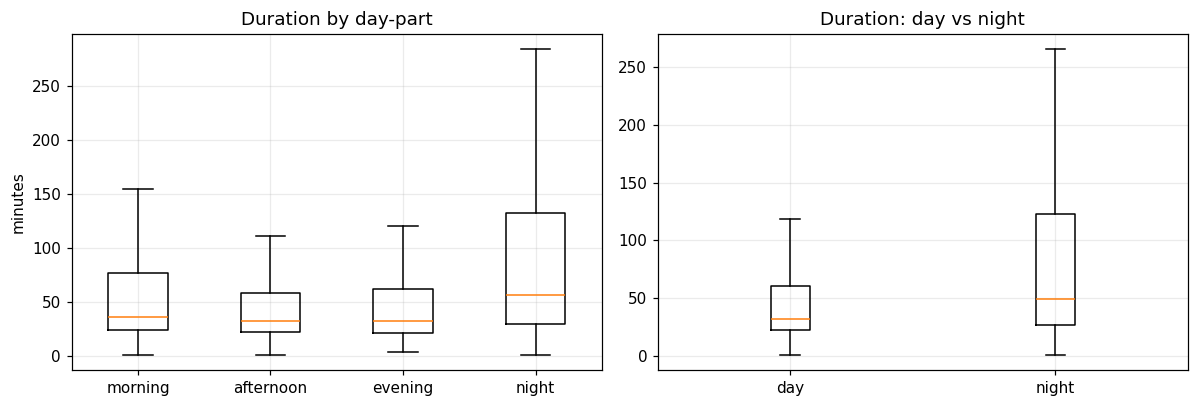

In [12]:
# Fig 3 — duration by day-part and by day/night
order = ["morning","afternoon","evening","night"]
fig, ax = plt.subplots(1, 2, figsize=(11,3.8))
ax[0].boxplot([df.loc[df.day_part==p,"duration_min"] for p in order],
              labels=order, showfliers=False)
ax[0].set(title="Duration by day-part", ylabel="minutes")
dn = df.dropna(subset=["is_night"])
ax[1].boxplot([dn.loc[~dn.is_night,"duration_min"], dn.loc[dn.is_night,"duration_min"]],
              labels=["day","night"], showfliers=False)
ax[1].set(title="Duration: day vs night")
plt.tight_layout(); plt.savefig(OUTDIR/"fig3_duration_by_time.png", bbox_inches="tight"); plt.show()

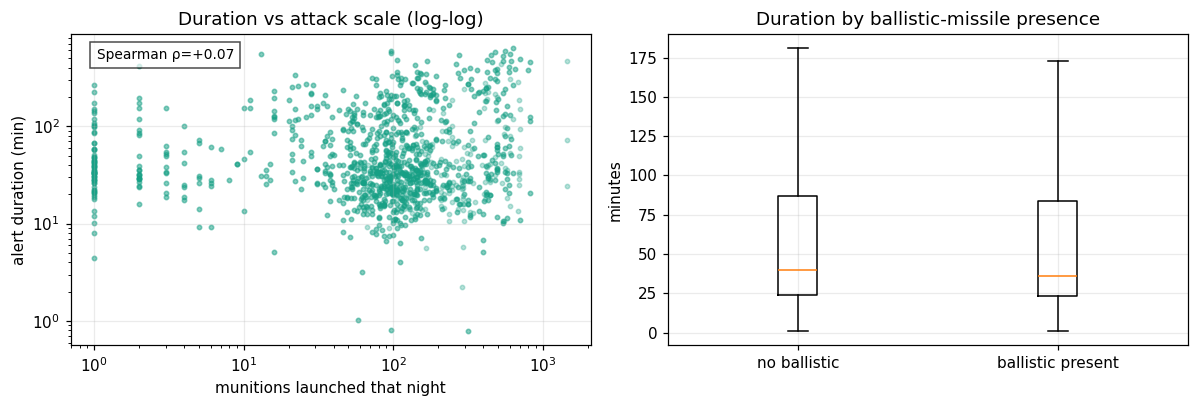

In [13]:
# Fig 4 — duration vs attack scale (only nights with a recorded attack)
sub = df[df["total_launched"]>0]
fig, ax = plt.subplots(1, 2, figsize=(11,3.8))
ax[0].scatter(sub["total_launched"], sub["duration_min"], s=8, alpha=.3, color="#16a085")
ax[0].set(xscale="log", yscale="log", xlabel="munitions launched that night",
          ylabel="alert duration (min)", title="Duration vs attack scale (log-log)")
if len(sub) > 2:
    rho,_ = stats.spearmanr(sub["duration_min"], sub["total_launched"])
    ax[0].text(.05,.92, f"Spearman ρ={rho:+.2f}", transform=ax[0].transAxes,
               fontsize=9, bbox=dict(fc="white", alpha=.7))
ax[1].boxplot([df.loc[~df.has_ballistic,"duration_min"], df.loc[df.has_ballistic,"duration_min"]],
              labels=["no ballistic","ballistic present"], showfliers=False)
ax[1].set(title="Duration by ballistic-missile presence", ylabel="minutes")
plt.tight_layout(); plt.savefig(OUTDIR/"fig4_duration_vs_weapons.png", bbox_inches="tight"); plt.show()

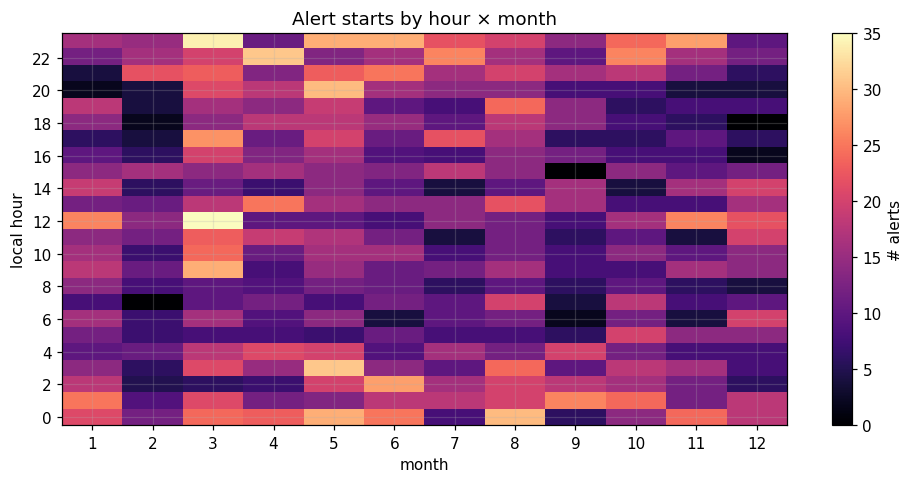

In [14]:
# Fig 5 — bonus: alert frequency heatmap, hour × month
piv = (df.assign(hour=df["start_local"].dt.hour, month=df["start_local"].dt.month)
         .pivot_table(index="hour", columns="month", values="duration_min", aggfunc="count")
         .reindex(index=range(24)))
fig, ax = plt.subplots(figsize=(9,4.5))
im = ax.imshow(piv.fillna(0), aspect="auto", origin="lower", cmap="magma")
ax.set(xlabel="month", ylabel="local hour", title="Alert starts by hour × month",
       xticks=range(len(piv.columns)), yticks=range(0,24,2))
ax.set_xticklabels(piv.columns); ax.set_yticklabels(range(0,24,2))
fig.colorbar(im, label="# alerts")
plt.tight_layout(); plt.savefig(OUTDIR/"fig5_hour_month_heatmap.png", bbox_inches="tight"); plt.show()

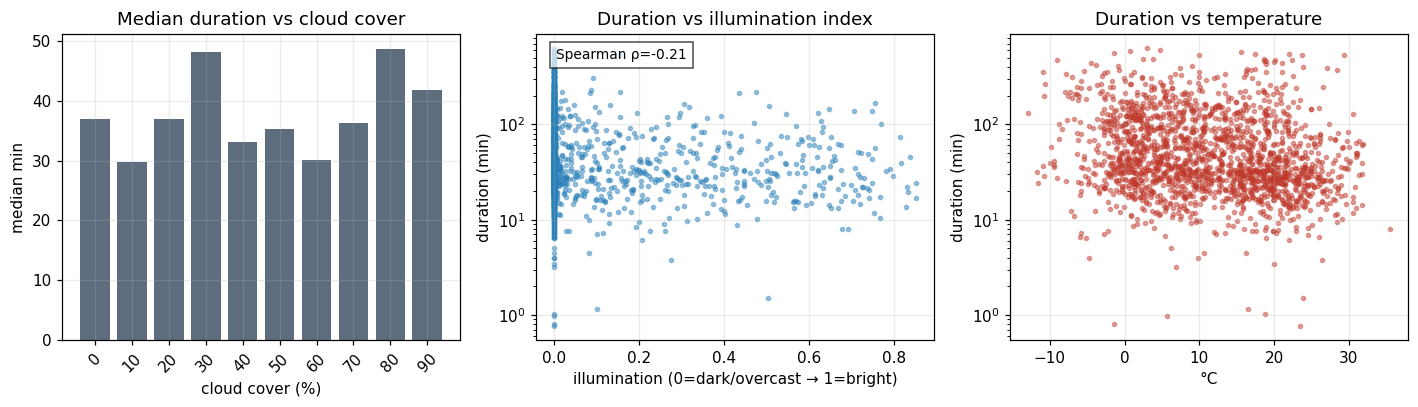

In [15]:
# Fig 6 — weather panel for H3 (only drawn when real weather is present)
if not WEATHER_AVAILABLE:
    print("Fig 6 skipped — no real weather in this run.")
else:
    def binned_medians(x, y, bins):
        idx = pd.cut(x, bins)
        g = pd.DataFrame({"y": y}).groupby(idx, observed=True)["y"]
        return g.median(), g.size()
    fig, ax = plt.subplots(1, 3, figsize=(13, 3.8))
    # duration vs cloud cover (binned median)
    s = df[["duration_min","cloud_pct"]].dropna()
    med, _ = binned_medians(s["cloud_pct"], s["duration_min"], np.arange(0,101,10))
    ax[0].bar([str(int(i.left)) for i in med.index], med.values, color="#34495e", alpha=.8)
    ax[0].set(title="Median duration vs cloud cover", xlabel="cloud cover (%)", ylabel="median min")
    ax[0].tick_params(axis="x", labelrotation=45)
    # duration vs illumination index (scatter, log y)
    s = df[["duration_min","illumination"]].dropna()
    ax[1].scatter(s["illumination"], s["duration_min"], s=7, alpha=.25, color="#2980b9")
    ax[1].set(yscale="log", title="Duration vs illumination index",
              xlabel="illumination (0=dark/overcast → 1=bright)", ylabel="duration (min)")
    rho,_ = stats.spearmanr(s["illumination"], s["duration_min"])
    ax[1].text(.05,.92,f"Spearman ρ={rho:+.2f}", transform=ax[1].transAxes,
               bbox=dict(fc="white", alpha=.7), fontsize=9)
    # duration vs temperature (scatter, log y)
    s = df[["duration_min","temp_c"]].dropna()
    ax[2].scatter(s["temp_c"], s["duration_min"], s=7, alpha=.25, color="#c0392b")
    ax[2].set(yscale="log", title="Duration vs temperature", xlabel="°C", ylabel="duration (min)")
    plt.tight_layout(); plt.savefig(OUTDIR/"fig6_weather_panel.png", bbox_inches="tight"); plt.show()

## Summary, caveats, and switching to fully-real data

**What is real in this run.** The alert series and everything derived only from it —
duration distribution, start-time-of-day, day/night split, solar elevation, moon phase, and
the **H1** tests — are computed on the **official Kyiv alert records**. Those H1 statistics are real.

**Weather is real-only, never synthetic.** Step 2 fetches genuine Open-Meteo archive data;
any hour it can't return stays `NaN` and is flagged in the coverage report (`WEATHER_AVAILABLE`
indicates whether any real weather was retrieved). **H3** runs only on non-missing rows and
prints the n used / n missing; if the API is unreachable it reports "data unavailable" rather
than inventing values. So when you run this on an open network, the H3 numbers are real.

**Weapons** still use the labelled-synthetic demo (`WEAPONS_IS_SYNTHETIC`) until a Kaggle token
is present, so **H2** is a methodology demonstration until then. (Say the word if you'd like the
same real-or-missing treatment applied to weapons.)

**To make every remaining layer real**, run locally where the network is open:
1. Weather — nothing to do; Open-Meteo is free and keyless and is used automatically.
2. Weapons — `pip install kagglehub`, set `KAGGLE_USERNAME` / `KAGGLE_KEY`, and the real
   Kaggle loader is used automatically.

**Interpretation caveats to carry into any write-up.**
- **Illumination ≈ day/night.** Because the illumination index is largely a continuous version
  of darkness, an `illumination ↔ duration` correlation overlaps the H1 night effect. H3(c)'s
  `solar_elev × cloud_pct` model is the honest test of whether **cloud cover adds anything
  beyond sun position** — lean on that, not the raw Spearman, for the causal-flavoured claim.
- **Seasonal confounding.** Cold/cloudy months coincide with winter strike campaigns, so weather
  effects can be campaign effects; the month fixed-effects in H3(b)/(c) absorb most of this.
- Weapons are **national daily aggregates** (H2 is a night-level association, not causation).
- Alerts come in **autocorrelated waves**, so treat p-values as optimistic and weight effect sizes.
- A 2025 shift to district-level alerts in some regions affects how duration is defined over time;
  this notebook uses the consistent **city-wide** Kyiv series throughout.